In [29]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

More tutorials on opencv can be found:

https://docs.opencv.org/master/d2/d96/tutorial_py_table_of_contents_imgproc.html

In [30]:
path = "tetris_blocks.png"

# Image input and initial processing
Load the input image (whose path was supplied via command line argument) and display the image to our screen:

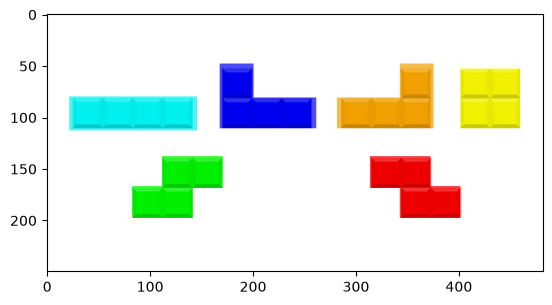

In [31]:
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
plt.imshow(image)

Convert the image to grayscale:

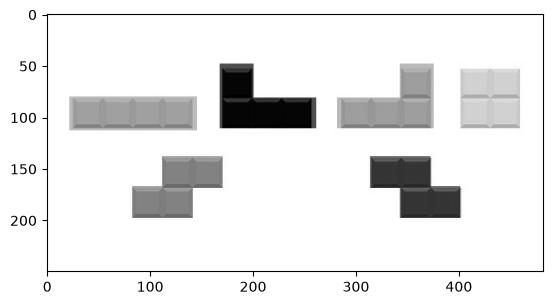

In [32]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

# Advanced processing
Apply edge detection, so we can find the outlines of objects in images:


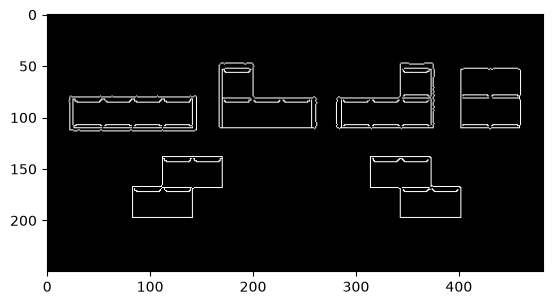

In [33]:
edged = cv2.Canny(gray, 30, 150)
plt.imshow(edged, cmap='gray')

Threshold the image by setting all pixel values equal to or less than 225 to 255 (white; foreground): $x \le 225 \rightarrow x = 255$ and all pixel values greater than 225 to 0 (black; background): $x \gt 225 \rightarrow x=0$

Thereby we are segmenting the image.

Both the threshold (e.g. 225 in our case) and the value for pixels less than the threshold in the resulting image (255 in our case) can be tweaked.

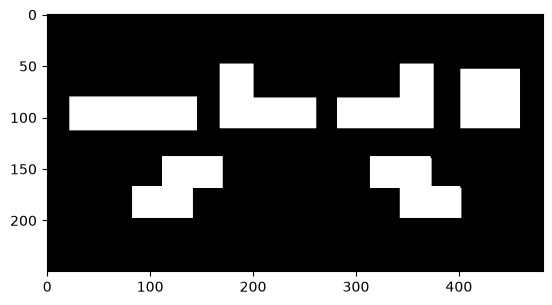

In [34]:
threshold = 225
threshold_value = 255

thresh = cv2.threshold(gray, threshold, threshold_value, cv2.THRESH_BINARY_INV)[1]
plt.imshow(thresh, cmap='gray')

Find contours (i.e., outlines) of the foreground objects in the thresholded image:

In [35]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()

Loop over the contours:

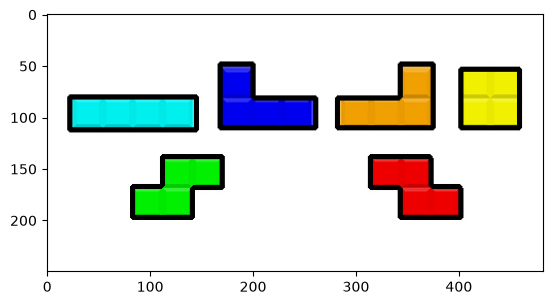

In [36]:
for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)

Draw the total number of contours found in purple:

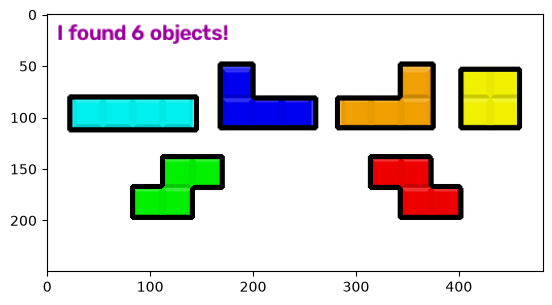

In [37]:
text = "I found {} objects!".format(len(cnts))
cv2.putText(output, text, (10, 25),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (155, 0, 155), 2)
plt.imshow(output)

We apply erosions to reduce the size of foreground objects:

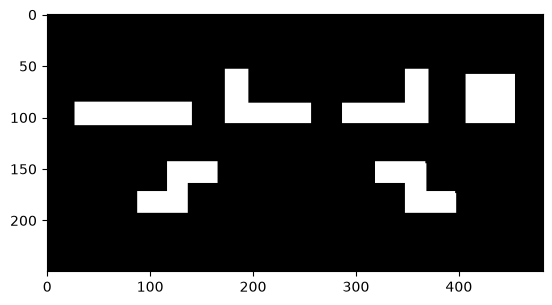

In [38]:
mask = thresh.copy()
mask = cv2.erode(mask, None, iterations = 5)
plt.imshow(mask, cmap = 'gray')

Similarly, dilations can increase the size of the ground objects:

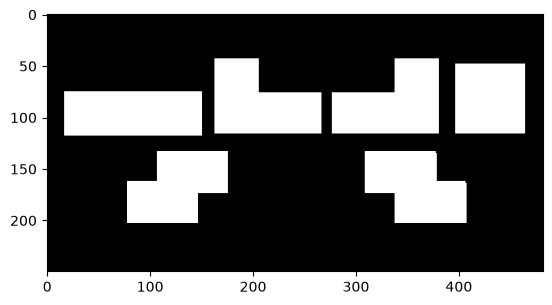

In [39]:
mask = thresh.copy()
mask = cv2.dilate(mask, None, iterations = 5)
plt.imshow(mask, cmap='gray')

A typical operation we may want to apply is to take our mask and apply a bitwise `AND` to our input image, keeping only the masked regions:

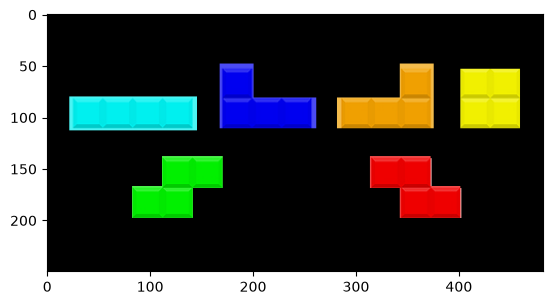

In [40]:
mask = thresh.copy()
output = cv2.bitwise_and(image, image, mask=mask)
plt.imshow(output)

# Exercise 2
1. Can you remove the yellow square from the image?
2. Go through the tutoria, but with the `spheres.png` image. (replace `tetris_blocks.png` with `spheres.png`)
3. Tweak the parameters of the thresholding. Can you threshold all the spheres?
4. Can you remove the red sphere?
5. Can you remove the green sphere?

1. I want to remove the yellow box which is the only square box I have. 

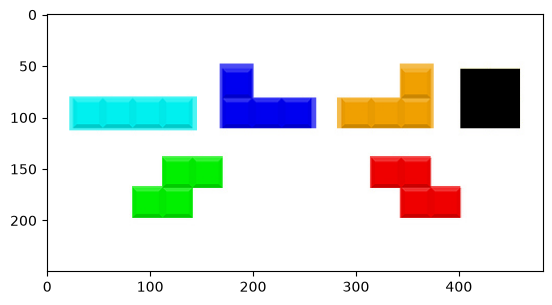

In [45]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()

for c in cnts:
    x, y, w, h = cv2.boundingRect(c) # x, y are the top-left coordinates, w is the widht, h is the height
    aspect_ratio = float(w) / h
    
    if 1.0 <= aspect_ratio <= 1.0:
        # draw each contour on the output image with a 3px thick black outline
        cv2.drawContours(output, [c], -1, (0, 0, 0), -1)
    
plt.imshow(output)
        


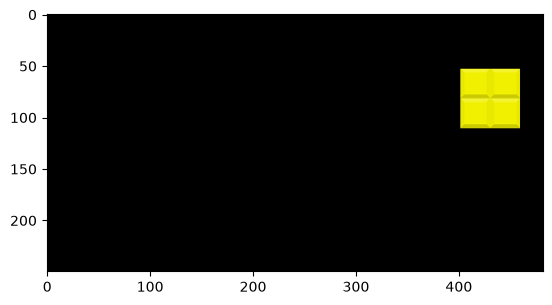

In [46]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

# Start with a completely black output image instead of a copy of the original
output = np.zeros_like(image)

for c in cnts:
    x, y, w, h = cv2.boundingRect(c) # x, y are the top-left coordinates, w is the width, h is the height
    aspect_ratio = float(w) / h
    
    # Use a small range around 1.0 to ensure precision floating-point differences don't miss it
    if 0.95 <= aspect_ratio <= 1.05:
        # Create a mask for just this square contour
        mask = np.zeros(gray.shape, dtype="uint8")
        cv2.drawContours(mask, [c], -1, 255, -1)
        
        # Copy the yellow square pixels from original image to output image
        output[mask == 255] = image[mask == 255]
    
plt.imshow(output)

Na prosthesw kwdika poy me tis akriveis diastaseis tou box tha mporw na to diagrapsw entelws apo thn arxikh eikona kai na to prosthesw olokliro stin arxiki eikona

Exercise 2:

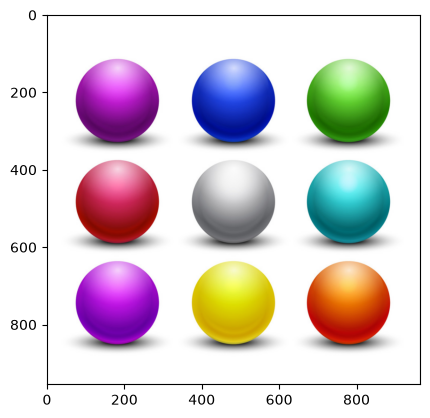

In [48]:

import math
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

# 1. Update image path
path = "spheres.png"

# Load image and convert BGR to RGB for Matplotlib
bgr_img = cv2.imread(path)
b, g, r = cv2.split(bgr_img)
image = cv2.merge([r, g, b])

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()

for c in cnts:
    # Calculate area and perimeter of the contour
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    
    # Avoid division by zero for tiny noise contours
    if perimeter > 0:
        circularity = (4 * math.pi * area) / (perimeter ** 2)
        
        # Check if the shape is roughly circular (close to 1.0)
        if 0.8 <= circularity <= 1.2:
            # Fill the circular contour with black to remove it
            cv2.drawContours(output, [c], -1, (0, 0, 0), -1)

plt.imshow(output)